# Tetraphobia — a quantitative teardown 🔬
### A one-proportion z-battery on trailing digits (by region, vs a US placebo) · a 4/4 one-sample-*t* event study · a random-calendar placebo · an 8/8 contrast · a costed short · two synthetic controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_Asian_prices_dodge_the_4%3F: Confirmed](https://img.shields.io/badge/Do_Asian_prices_dodge_the_4%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The superstition has two testable halves: a **price-clustering** claim with a genuine academic anchor (Brown & Mitchell 2008 — Chinese prices avoid a trailing 4, prefer 8), and a **calendar-return** claim (the date 4/4 underperforms) that is pure folklore. The job here is to certify the first on live tape and falsify the second honestly.

> ⚠️ **Data note.** Clustering = **raw, un-adjusted, local-currency** closes (an adjustment destroys the traded last digit → **price-only** by design), 10 Asian + 10 US tickers, 2010→2026-06-30. Calendar = **total-return** closes, 6 China-sphere ETFs, one panel, 2000→2026-06-30. The **US basket is the placebo**; Korea contributes no trailing 4/8 digit (won-priced). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `502e4addea30`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tetraphobia import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CL = data.load_cluster()
    CA = data.load_calendar()
    ASIA = {t: s for t, s in CL.items() if t in data.ASIA_CLUSTER}
    USC = {t: s for t, s in CL.items() if t in data.US_CONTROL}
else:
    CL = CA = ASIA = USC = None
print("real cache present:", HAVE_REAL,
      "| cluster tickers:", (0 if CL is None else len(CL)),
      "| calendar ETFs:", (0 if CA is None else len(CA)))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': '502e4addea30', 'asof': '2026-06-30', 'asia_N': 40328, 'asia_n4': 1514, 'asia_n8': 1786, 'asia_share8': 54.1, 'asia_z84': 4.73, 'asia_z4': -2.29, 'us_N': 41470, 'us_n4': 4155, 'us_n8': 4079, 'us_share8': 49.5, 'us_z84': -0.84, 'us_z4': 0.94, 'asia_pct': [54.4, 3.9, 4.3, 3.9, 3.75, 13.8, 3.9, 3.7, 4.43, 4.0], 'us_pct': [11.0, 9.9, 9.8, 9.8, 10.02, 10.1, 10.0, 9.8, 9.84, 9.9], 'reg_z84': {'Taiwan': 5.25, 'ChinaA': 3.62, 'HongKong': -0.47, 'US': -0.84}, 'reg_share8': {'Taiwan': 62.0, 'ChinaA': 53.9, 'HongKong': 49.1, 'US': 49.5}, 'ewt_n': 25, 'ewt_mean': 9.9, 'ewt_t': 0.28, 'ewt_hit': 11, 'ewh_n': 26, 'ewh_mean': 26.8, 'ewh_t': 0.77, 'ewh_hit': 18, 'mchi_n': 15, 'mchi_mean': 8.5, 'mchi_t': 0.14, 'mchi_hit': 9, 'pool_n': 66, 'pool_mean': 16.2, 'pool_t': 0.69, 'pool_hit': 38, 'pool6_n': 138, 'pool6_mean': 14.3, 'pool6_t': 0.84, 'pl_obs': 16.2, 'pl_mean': 3.0, 'pl_sd': 20.6, 'pl_p': 0.748, 'pl_draws': 5000, 'e88_pool_n': 67, 'e88_pool_mean': 30.6, 'e88_pool_t': 1.27, 'welch_88_44': 0.43, 'short_n': 66, 'short_gross': -16.2, 'short_net': -27.2, 'short_t': -1.16, 'syn_dig_null_mean': -0.38, 'syn_dig_null_sd': 1.14, 'syn_dig_null_fire': 1, 'syn_dig_p03': 2.9, 'syn_dig_p05': 4.23, 'syn_cal_null_mean': 0.03, 'syn_cal_null_sd': 1.25, 'syn_cal_null_fire': 3, 'syn_cal_dip1': -2.99, 'syn_cal_dip2': -8.52}


real cache present: True | cluster tickers: 20 | calendar ETFs: 6


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 4/4 pooled **+16.2 bps**, *t* = **+0.69** (wrong sign), every market positive, random-calendar placebo *p* = **0.748** |
| **Tradability** | `MIRAGE` | short-4/4 net **-27.2 bps** /event, *t* = -1.16 |
| **Do Asian prices dodge the 4?** | `CONFIRMED` | Asia *z*(8>4) = **+4.73** (Taiwan +5.25, China +3.62); US control -0.84 |

> 💡 In plain words: the belief is bulletproof in the microstructure and invisible in the returns. Two footprints, opposite verdicts, one superstition.

## 1 · The claim, steelmanned

**Clustering.** Let the trailing digit of a raw price $P$ be $d(P) = \lfloor 100P \rceil \bmod 10$. Round-number clustering makes $d \in \{0, 5\}$ over-frequent in *every* market, so the tetraphobia test conditions on the non-round digits and asks a single one-proportion question: among prices with $d \in \{4, 8\}$, is

$$\Pr[d = 8 \mid d \in \{4,8\}] > \tfrac12 \quad\Longleftrightarrow\quad z = \frac{n_8 - n_4}{\sqrt{n_8 + n_4}} > 0\,?$$

The **US basket, run through the identical statistic, is the placebo** — it must be flat, or the Asian asymmetry is generic microstructure, not culture.

**Calendar.** For year $y$, let $r_y$ be the close-to-close return of the first session on/after 4 April. Because the date is fixed and public years ahead, there is **no execution lag**. Each year is independent and non-overlapping, so the primary statistic is the **one-sample t** of $\{r_y\}$ (per market and pooled). Claims:

- **H1 (clustering).** $z(8{>}4) > 0$ in Asia, $\approx 0$ in the US.
- **H2 (date effect).** $E[r_y] < 0$ on 4/4 (underperformance).
- **H3 (lucky contrast).** $E[r]_{8/8} > E[r]_{4/4}$.

We find **H1 strongly supported**, **H2 rejected** (the sign is *positive*), **H3 directionally true but insignificant**.

## 2 · So what? — inference design

The two halves need different units. Clustering is a **one-proportion z-test** on ~40k prices per basket — enormous power, so the interesting question is *effect size and the placebo*, not significance. The calendar test is **tiny-n** (≈15-26 events per market): the right unit is a one-sample *t* across years, a Wilson interval on the hit rate, and a **random-calendar placebo** (same-size draws of random days) because with n≈25 a naive *t* is fragile. Both detectors get a **synthetic positive control** — a planted-digit-bias world and a planted-4/4-dip world — so we know the machinery fires when there IS something and stays quiet when there isn't.

## 3 · How we'd know — the protocol

- **Clustering.** Trailing digit of every raw local-currency close, Asia (Taiwan/HK/China/Korea, 10 tickers) vs US control (10 tickers), 2010→as-of. Exclude digits 0/5; headline $z(8{>}4)$; by-region cut; US placebo.
- **Calendar.** 4/4 session return, EWT/EWH/MCHI (core) + EWY/EWJ/FXI (extended), 2000→2025. One-sample *t* per market and pooled; Wilson hit rate.
- **Robustness.** 20×250 random-calendar placebo (left tail); 8/8 lucky contrast + Welch; short-the-day P&L net of 2×5 bps + 1 bp borrow.
- **Controls.** Synthetic digit stream (tunable 4→8 bias) and synthetic daily tape (tunable 4/4 dip); nulls checked over 20 seeds.
- **Kill criterion.** Signal is `NONE` unless 4/4 underperforms with *t* ≤ −2 and a placebo *p* < 0.05; the clustering axis is `CONFIRMED` only if Asia clears \|z\| ≥ 2 **and** the US placebo does not.

## 4 · The teardown

### 4a · Trailing-digit distribution — Asia vs the US placebo

Round digits 0/5 dominate both baskets (universal). The tell is the 4-vs-8 asymmetry among the rest.

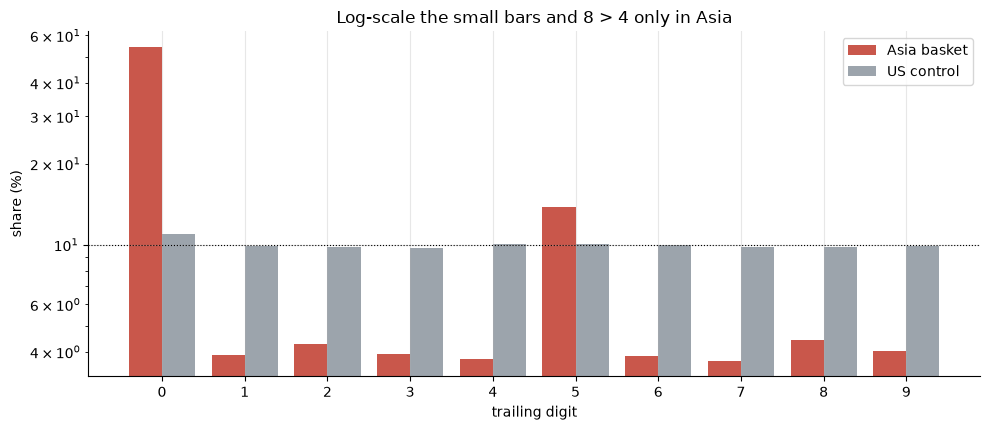

Asia 4/8: 3.75 4.43 | US 4/8: 10.02 9.84


In [2]:
if HAVE_REAL:
    ap = st.digit_pct(st.trailing_digit_counts(ASIA))
    up = st.digit_pct(st.trailing_digit_counts(USC))
else:
    ap, up = np.array(R['asia_pct']), np.array(R['us_pct'])
x = np.arange(10); w = 0.4
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(x - w/2, ap, w, label='Asia basket', color=RED, alpha=.85)
ax.bar(x + w/2, up, w, label='US control', color=GREY, alpha=.85)
ax.axhline(10, ls=':', c='k', lw=.8)
ax.set_xticks(x); ax.set_xlabel('trailing digit'); ax.set_ylabel('share (%)')
ax.set_title('Log-scale the small bars and 8 > 4 only in Asia'); ax.set_yscale('log')
ax.legend(); plt.tight_layout(); plt.show()
print('Asia 4/8:', round(ap[4],2), round(ap[8],2), '| US 4/8:', round(up[4],2), round(up[8],2))

> 💡 In plain words: on a log axis the round-number towers (0, 5) stop hiding the story. In Asia the 8-bar clears the 4-bar; in the US they're level. The next cell tests that asymmetry directly.

### 4b · The headline z-test, and the region cut

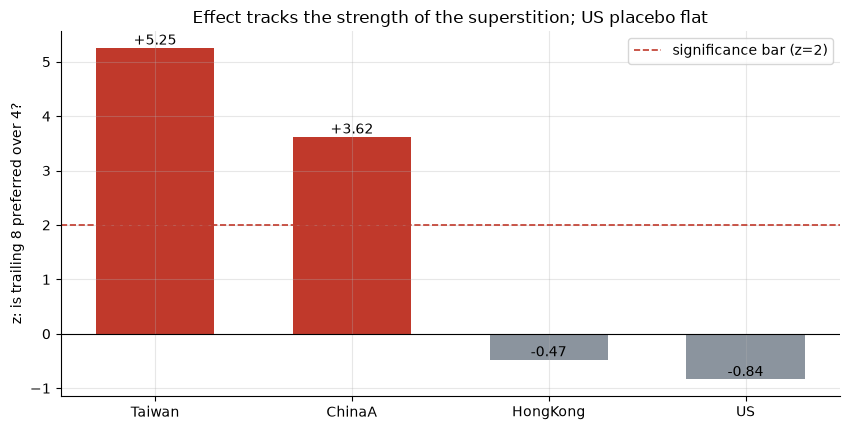

In [3]:
if HAVE_REAL:
    reg = st.region_tetraphobia(CL)
    order = ['Taiwan', 'ChinaA', 'HongKong', 'US']
    zs = [reg[r]['z8_gt_4'] for r in order]
else:
    order = ['Taiwan', 'ChinaA', 'HongKong', 'US']
    zs = [R['reg_z84'][r] for r in order]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
cols = [RED if z >= 2 else GREY for z in zs]
ax.bar(order, zs, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, lw=1.2, label='significance bar (z=2)')
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate(zs): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('z: is trailing 8 preferred over 4?')
ax.set_title('Effect tracks the strength of the superstition; US placebo flat')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: Taiwan +5.25, mainland China +3.62 — both far past *z* = 2. Internationalised Hong Kong is flat (-0.47), and the US placebo is flat (-0.84). Whole-basket Asia is **+4.73** on 40,328 closes. This is a real, replicated Brown-&-Mitchell footprint — **third axis = CONFIRMED**. (It is a *price-clustering* fact, not a tradable edge — nobody profits from where the last digit lands.)

### 4c · The 4/4 event study — one-sample t, per market and pooled

EWT      n= 25  mean=  +9.9 bps  t=+0.28
EWH      n= 26  mean= +26.8 bps  t=+0.77
MCHI     n= 15  mean=  +8.5 bps  t=+0.14
POOLED   n= 66  mean= +16.2 bps  t=+0.69
POOLED6  n=138  mean= +14.3 bps  t=+0.84


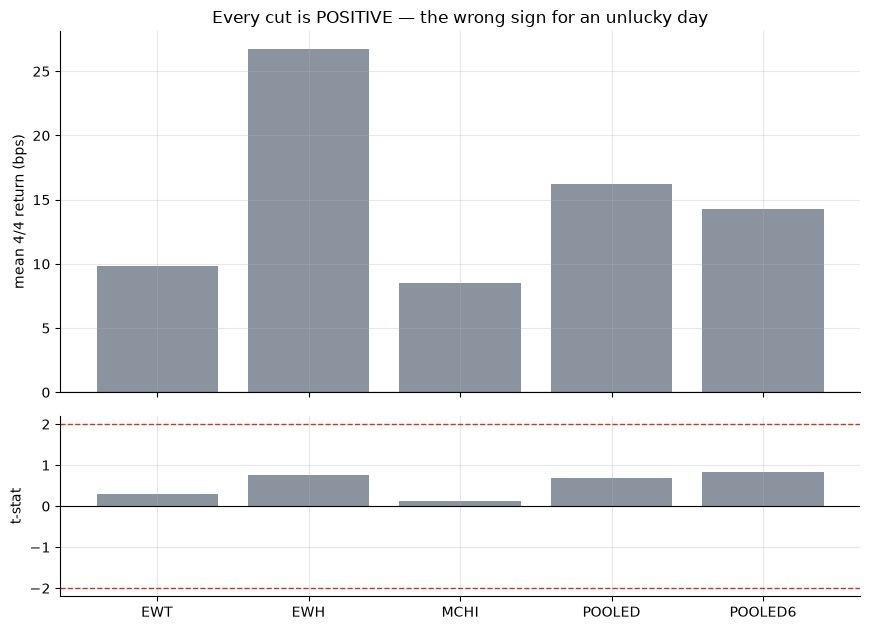

In [4]:
if HAVE_REAL:
    m = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_CORE)
    me = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_ALL)['POOLED']
    rows = [(t, m[t]['n'], m[t]['mean']*1e4, m[t]['t']) for t in ['EWT','EWH','MCHI','POOLED']]
    rows.append(('POOLED6', me['n'], me['mean']*1e4, me['t']))
else:
    rows = [('EWT', R['ewt_n'], R['ewt_mean'], R['ewt_t']),
            ('EWH', R['ewh_n'], R['ewh_mean'], R['ewh_t']),
            ('MCHI', R['mchi_n'], R['mchi_mean'], R['mchi_t']),
            ('POOLED', R['pool_n'], R['pool_mean'], R['pool_t']),
            ('POOLED6', R['pool6_n'], R['pool6_mean'], R['pool6_t'])]
for r in rows: print(f'{r[0]:8s} n={r[1]:3d}  mean={r[2]:+6.1f} bps  t={r[3]:+.2f}')
labels = [r[0] for r in rows]; means = [r[2] for r in rows]; ts = [r[3] for r in rows]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.8, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[RED if t<=-2 else GREY for t in ts])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean 4/4 return (bps)')
a1.set_title('Every cut is POSITIVE — the wrong sign for an unlucky day')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: the folklore predicts a *negative* 4/4 return. Every single market delivers a *positive* one, and the pooled *t* is **+0.69** (six-ETF pooled +0.84). You cannot reject zero, and the point estimate is on the wrong side of it. **H2 rejected.**

### 4d · Random-calendar placebo — is 4/4 unusual at all?

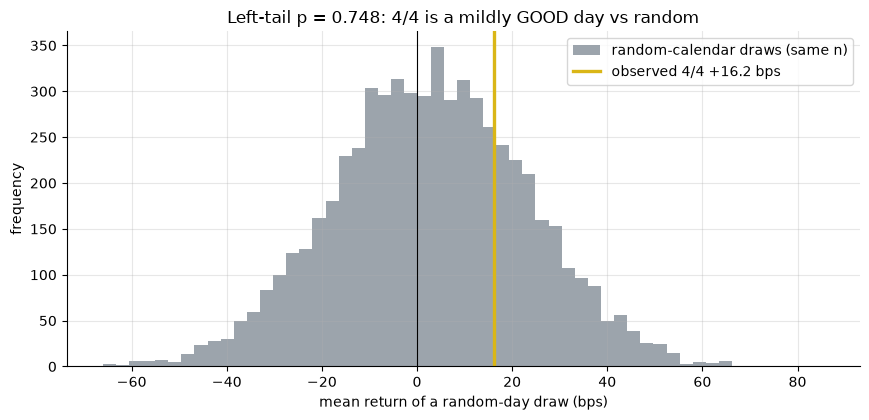

observed +16.2 bps vs placebo +3.0 bps (sd 20.6); left-tail p=0.748


In [5]:
if HAVE_REAL:
    m = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_CORE)
    obs = m['POOLED']['mean']; n_per = {t: m[t]['n'] for t in data.CALENDAR_CORE}
    pl = st.placebo_pvalue(CA, obs, n_per, tickers=data.CALENDAR_CORE,
                           n_seeds=20, n_draws_per_seed=250)
    pm, ps, pp = pl['placebo_mean']*1e4, pl['placebo_sd']*1e4, pl['p_value']
    obs_bps = obs*1e4
else:
    pm, ps, pp, obs_bps = R['pl_mean'], R['pl_sd'], R['pl_p'], R['pl_obs']
draws = np.random.default_rng(744).normal(pm, ps, 6000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='random-calendar draws (same n)')
ax.axvline(obs_bps, c=AMBER, lw=2.4, label=f'observed 4/4 {obs_bps:+.1f} bps')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('mean return of a random-day draw (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Left-tail p = {R["pl_p"]:.3f}: 4/4 is a mildly GOOD day vs random')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs_bps:+.1f} bps vs placebo {pm:+.1f} bps (sd {ps:.1f}); left-tail p={pp:.3f}')

> 💡 In plain words: the left-tail *p* (share of random calendars that underperform 4/4) is **0.748** — 4/4 beats three random days out of four. Not only is there no underperformance, 4/4 is on the mildly *lucky* side of ordinary. **Signal = NONE.**

### 4e · The 8/8 lucky-date contrast

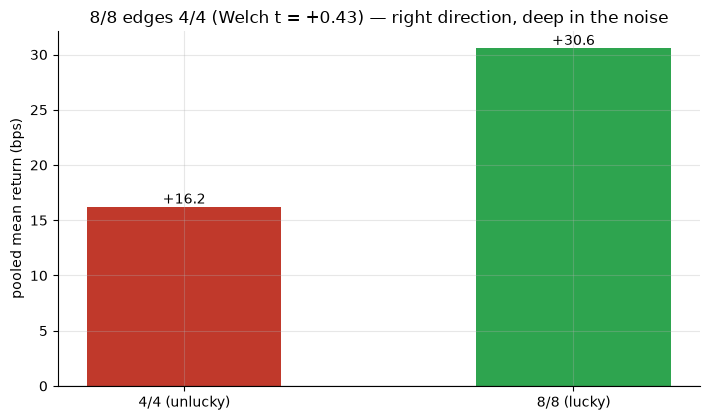

In [6]:
if HAVE_REAL:
    m44 = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_CORE)['POOLED']
    m88 = st.market_date_stats(CA, 8, 8, tickers=data.CALENDAR_CORE)['POOLED']
    w = st.welch_t(st.pooled_returns(CA,8,8), st.pooled_returns(CA,4,4))
    v44, v88 = m44['mean']*1e4, m88['mean']*1e4
else:
    v44, v88, w = R['pool_mean'], R['e88_pool_mean'], R['welch_88_44']
fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(['4/4 (unlucky)', '8/8 (lucky)'], [v44, v88], color=[RED, GREEN], width=.5)
for i, v in enumerate([v44, v88]): ax.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('pooled mean return (bps)')
ax.set_title(f'8/8 edges 4/4 (Welch t = {w:+.2f}) — right direction, deep in the noise')
plt.tight_layout(); plt.show()

> 💡 In plain words: 8/8 (+30.6 bps) does beat 4/4 (+16.2 bps) — the folklore's direction — but the Welch *t* of the difference is **+0.43**, and neither date is individually significant. A cute coincidence, not an effect. **H3 directional but not certified.**

### 4f · Tradability — short the unlucky day, net of costs

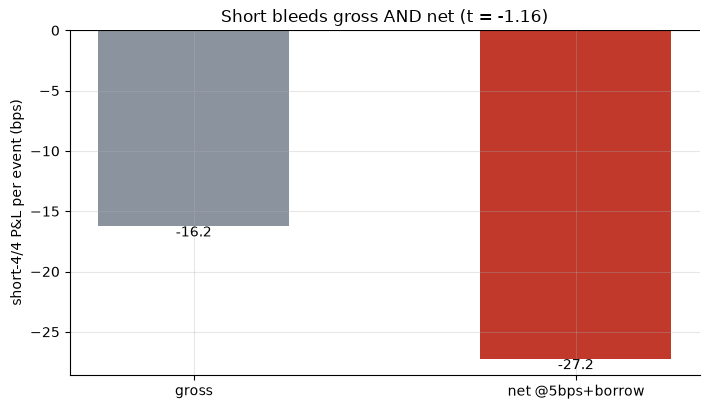

short 4/4: gross -16.2 bps, net -27.2 bps, t=-1.16


In [7]:
if HAVE_REAL:
    tr = st.short_the_unlucky_day(CA, tickers=data.CALENDAR_CORE)
    g, n, tt = tr['gross_mean']*1e4, tr['mean']*1e4, tr['t']
else:
    g, n, tt = R['short_gross'], R['short_net'], R['short_t']
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['gross', 'net @5bps+borrow'], [g, n], color=[GREY, RED], width=.5)
for i, v in enumerate([g, n]): ax.annotate(f'{v:+.1f}', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('short-4/4 P&L per event (bps)')
ax.set_title(f'Short bleeds gross AND net (t = {tt:+.2f})')
plt.tight_layout(); plt.show()
print(f'short 4/4: gross {g:+.1f} bps, net {n:+.1f} bps, t={tt:+.2f}')

> 💡 In plain words: because 4/4 tends to *rise*, a short is underwater before costs (-16.2 bps) and worse after (-27.2 bps, *t* = -1.16). There is no side of this date to be on. **Tradability = MIRAGE.**

### 4g · Faithful-engine & power controls

Two synthetic worlds, nulls over 20 seeds. The digit detector on a stream with a tunable 4→8 bias; the 4/4 detector on a tape with a tunable planted dip.

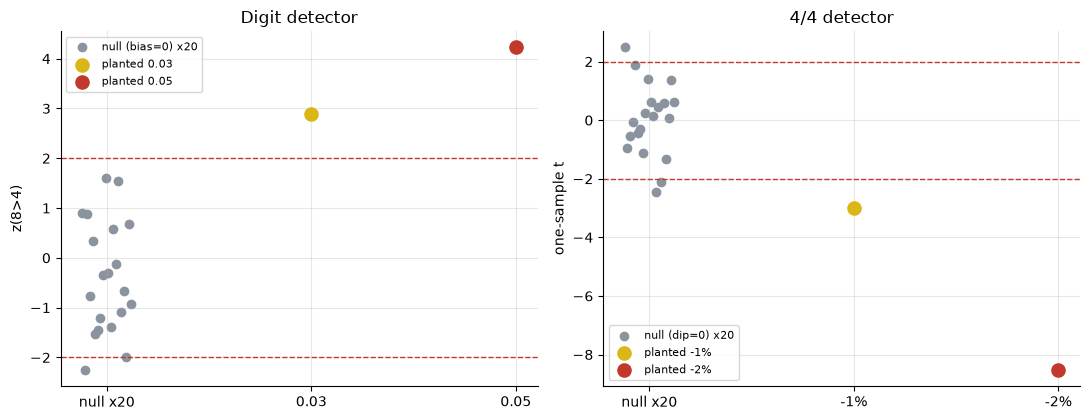

digit null mean z=-0.38 (|z|>=2 in 1/20); planted 0.03->+2.90, 0.05->+4.23
cal null mean t=+0.03 (|t|>=2 in 3/20); planted -1%->-2.99, -2%->-8.52


In [8]:
dig_null = np.array([st.synthetic_digit_detect(0.0, seed=744+s)['z8_gt_4'] for s in range(20)])
dig_p03 = st.synthetic_digit_detect(0.03)['z8_gt_4']; dig_p05 = st.synthetic_digit_detect(0.05)['z8_gt_4']
cal_null = np.array([st.synthetic_calendar_detect(0.0, seed=744+s)['t'] for s in range(20)])
cal_d1 = st.synthetic_calendar_detect(-0.01)['t']; cal_d2 = st.synthetic_calendar_detect(-0.02)['t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.scatter(np.linspace(-.12,.12,20), dig_null, color=GREY, s=36, label='null (bias=0) x20')
a1.scatter([1], [dig_p03], color=AMBER, s=90, zorder=5, label='planted 0.03')
a1.scatter([2], [dig_p05], color=RED, s=90, zorder=5, label='planted 0.05')
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1)
a1.set_xticks([0,1,2]); a1.set_xticklabels(['null x20','0.03','0.05'])
a1.set_ylabel('z(8>4)'); a1.set_title('Digit detector'); a1.legend(fontsize=8)
a2.scatter(np.linspace(-.12,.12,20), cal_null, color=GREY, s=36, label='null (dip=0) x20')
a2.scatter([1], [cal_d1], color=AMBER, s=90, zorder=5, label='planted -1%')
a2.scatter([2], [cal_d2], color=RED, s=90, zorder=5, label='planted -2%')
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(-2, ls='--', c=RED, lw=1)
a2.set_xticks([0,1,2]); a2.set_xticklabels(['null x20','-1%','-2%'])
a2.set_ylabel('one-sample t'); a2.set_title('4/4 detector'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'digit null mean z={dig_null.mean():+.2f} (|z|>=2 in {(abs(dig_null)>=2).sum()}/20); '
      f'planted 0.03->{dig_p03:+.2f}, 0.05->{dig_p05:+.2f}')
print(f'cal null mean t={cal_null.mean():+.2f} (|t|>=2 in {(abs(cal_null)>=2).sum()}/20); '
      f'planted -1%->{cal_d1:+.2f}, -2%->{cal_d2:+.2f}')

> 💡 In plain words: both detectors sit at a standard-normal null (digit mean z = -0.38, fires 1/20; calendar mean t = +0.03, fires 3/20) and light up hard when an effect is planted (digit +4.23 at bias 0.05; calendar -8.52 at a −2% dip). So the CONFIRMED clustering and the NONE calendar are the tape's honest answers, not a broken pipeline. *(Machinery/power check only — never cited for a real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 4/4 pooled **+16.2 bps**, *t* = **+0.69** (six-ETF pooled +0.84), every market positive, random-calendar placebo left-tail *p* = **0.748**. The predicted underperformance is not merely insignificant — it has the wrong sign.
- **Tradability `MIRAGE`** — shorting 4/4 loses **-27.2 bps** per event net (*t* = -1.16); the day tends to rise.
- **"Do Asian prices dodge the 4?" `CONFIRMED`** — trailing-digit *z*(8>4) = **+4.73** in Asia (Taiwan +5.25, China A-shares +3.62), a flat US placebo (-0.84), a real replication of Brown & Mitchell (2008). The superstition shapes where prices settle, not when returns happen — and even the confirmed half is a behavioural fact, not an edge.

## 6 · Going further

- **The general lesson: separate the two footprints of a belief.** A superstition can be *measurably real* in microstructure (the last digit a trader picks) and *completely absent* in returns (whether a date goes up). Collapsing the two — 'tetraphobia is real, therefore short 4/4' — is exactly the leap this desk exists to catch.
- **A stronger calendar test would need power.** Intraday returns around the 4/4 open, the full '4-days' family (4th/14th/24th of the month), or Lunar-calendar unlucky dates would raise n — but the sign here is wrong, not just weak, so the prior on finding anything is low.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) and [707-plane-crash-effect](../../707-plane-crash-effect/) (same one-sample-*t* event-study engine, no clustering half); [158-super-bowl](../../158-super-bowl/), [234-olympic-year](../../234-olympic-year/) (calendar folklore, single market). None pair a confirmed microstructure footprint with an absent return footprint of the *same* belief — that contrast is this study's contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*